In [1]:
import os
import pickle
import numpy as np
import torch
from model.UAV import *
from model.HAP import *
from testing_func.test_func import *

In [2]:
from network_models.multi_sat import get_sat
from network_models.cloud_model import *
sat_per_step = get_sat()
num_uav = 3
num_steps = 900
uav_pos_init = np.array([[0, 0, H_OGS],
                         [0, 0, H_OGS],
                         [0, 0, H_OGS]], dtype=np.float32)
user_positions = simulate_user_mobility(200, 901, distribution="normal", n_hotspot=1)
cloud_map = get_full_cloud_torch(cloud_size=6, device=device).squeeze().cpu().numpy()
HAP_position = np.array([750, 750, 20000], dtype=np.float32)



In [3]:
user_positions.shape

(200, 901, 2)

In [11]:
# nums_handover_DQN_arr = []
# nums_handover_random_arr = []
# nums_handover_best_arr = []
# RUAV_log_DQN_arr = [] 
# CFSO_log_DQN_arr = [] 
# RUAV_log_random_arr = [] 
# CFSO_log_random_arr = [] 
# RUAV_log_best_arr = [] 
# CFSO_log_best_arr = [] 
# HAP_bw_log_best_arr = []
# HAP_bw_log_random_arr = []
# HAP_bw_log_DQN_arr = []
for i in range(100):
    sat_per_step = get_sat()
    num_uav = 3
    num_steps = 900
    uav_pos_init = np.array([[0, 0, H_OGS],
                            [0, 0, H_OGS],
                            [0, 0, H_OGS]], dtype=np.float32)
    user_positions = simulate_user_mobility(200, 901, distribution="normal", n_hotspot=1)
    cloud_map = get_full_cloud_torch(cloud_size=6, device=device).squeeze().cpu().numpy()
    HAP_position = np.array([750, 750, 20000], dtype=np.float32)
    type_SAT="random"  # random, best, DQN
    RUAV_log_random, CFSO_log_random, uav_traj_random, alpha_all_random, beta_all_random, HAP_bw_log_random, nums_handover_random= evaluate_trained_policy_2(
        sat_per_step,device, num_uav, num_steps,
        uav_pos_init, user_positions, cloud_map, HAP_position,type_SAT, save_dir="D:\TOPIC 3\Minh_code\model_save"
    )
    type_SAT="best"  # random, best, DQN

    RUAV_log_best, CFSO_log_best, uav_traj_best, alpha_all_best, beta_all_best, HAP_bw_log_best, nums_handover_best= evaluate_trained_policy_2(
        sat_per_step,device, num_uav, num_steps,
        uav_pos_init, user_positions, cloud_map, HAP_position, type_SAT, save_dir="D:\TOPIC 3\Minh_code\model_save"
    )
    type_SAT="DQN"  # random, best, DQN
    RUAV_log_DQN, CFSO_log_DQN, uav_traj_DQN, alpha_all_DQN, beta_all_DQN, HAP_bw_log_DQN, nums_handover_DQN= evaluate_trained_policy_2(
        sat_per_step,device, num_uav, num_steps,
        uav_pos_init, user_positions, cloud_map, HAP_position, type_SAT, save_dir="D:\TOPIC 3\Minh_code\model_save"
    )
    nums_handover_DQN_arr.append(nums_handover_DQN)
    nums_handover_random_arr.append(nums_handover_random)
    nums_handover_best_arr.append(nums_handover_best)
    RUAV_log_DQN_arr.append(RUAV_log_DQN) 
    CFSO_log_DQN_arr.append(CFSO_log_DQN) 
    RUAV_log_random_arr.append(RUAV_log_random) 
    CFSO_log_random_arr.append(CFSO_log_random) 
    RUAV_log_best_arr.append(RUAV_log_best) 
    CFSO_log_best_arr.append(CFSO_log_best) 
    HAP_bw_log_best_arr.append(HAP_bw_log_best)
    HAP_bw_log_random_arr.append(HAP_bw_log_random)
    HAP_bw_log_DQN_arr.append(HAP_bw_log_DQN)
    print(f"Run {i} done")


Run 0 done


TypeError: list indices must be integers or slices, not NoneType

In [12]:
nums_handover_DQN

35

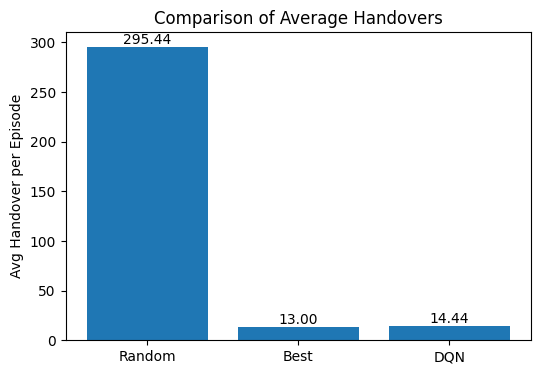

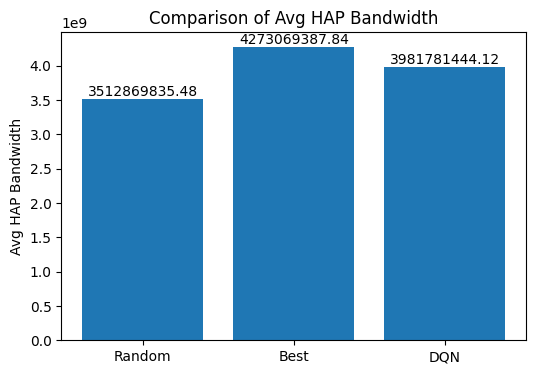

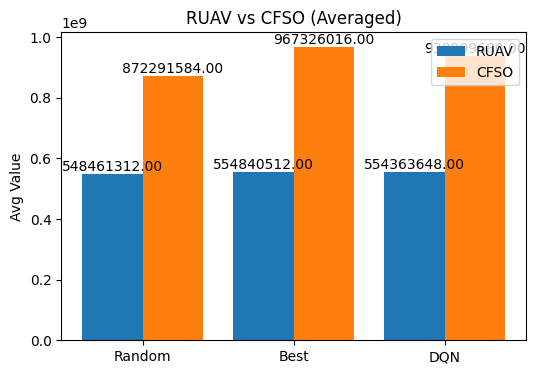

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- Handover ---
handover_mean_DQN = np.mean([np.mean(x) for x in nums_handover_DQN_arr])
handover_mean_random = np.mean([np.mean(x) for x in nums_handover_random_arr])
handover_mean_best = np.mean([np.mean(x) for x in nums_handover_best_arr])

plt.figure(figsize=(6,4))
vals = [handover_mean_random, handover_mean_best, handover_mean_DQN]
bars = plt.bar(["Random", "Best", "DQN"], vals)
plt.ylabel("Avg Handover per Episode")
plt.title("Comparison of Average Handovers")

# thêm giá trị trên cột
for bar, val in zip(bars, vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f"{val:.2f}", ha='center', va='bottom')

plt.show()

# --- HAP_bw ---
hap_bw_mean_DQN = np.mean([np.mean(x) for x in HAP_bw_log_DQN_arr])
hap_bw_mean_random = np.mean([np.mean(x) for x in HAP_bw_log_random_arr])
hap_bw_mean_best = np.mean([np.mean(x) for x in HAP_bw_log_best_arr])

plt.figure(figsize=(6,4))
vals = [hap_bw_mean_random, hap_bw_mean_best, hap_bw_mean_DQN]
bars = plt.bar(["Random", "Best", "DQN"], vals)
plt.ylabel("Avg HAP Bandwidth")
plt.title("Comparison of Avg HAP Bandwidth")

for bar, val in zip(bars, vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f"{val:.2f}", ha='center', va='bottom')

plt.show()

# --- RUAV vs CFSO ---
ruav_mean_DQN = np.mean([np.mean(x) for x in RUAV_log_DQN_arr])
ruav_mean_random = np.mean([np.mean(x) for x in RUAV_log_random_arr])
ruav_mean_best = np.mean([np.mean(x) for x in RUAV_log_best_arr])

cfso_mean_DQN = np.mean([np.mean(x) for x in CFSO_log_DQN_arr])
cfso_mean_random = np.mean([np.mean(x) for x in CFSO_log_random_arr])
cfso_mean_best = np.mean([np.mean(x) for x in CFSO_log_best_arr])

plt.figure(figsize=(6,4))
x = np.arange(3)
width = 0.35
ruav_vals = [ruav_mean_random, ruav_mean_best, ruav_mean_DQN]
cfso_vals = [cfso_mean_random, cfso_mean_best, cfso_mean_DQN]

bars1 = plt.bar(x-0.2, ruav_vals, width=0.4, label="RUAV")
bars2 = plt.bar(x+0.2, cfso_vals, width=0.4, label="CFSO")
plt.xticks(x, ["Random", "Best", "DQN"])
plt.ylabel("Avg Value")
plt.title("RUAV vs CFSO (Averaged)")
plt.legend()

# thêm giá trị trên cột RUAV
for bar, val in zip(bars1, ruav_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f"{val:.2f}", ha='center', va='bottom')

# thêm giá trị trên cột CFSO
for bar, val in zip(bars2, cfso_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f"{val:.2f}", ha='center', va='bottom')

plt.show()


NameError: name 'RUAV_log' is not defined

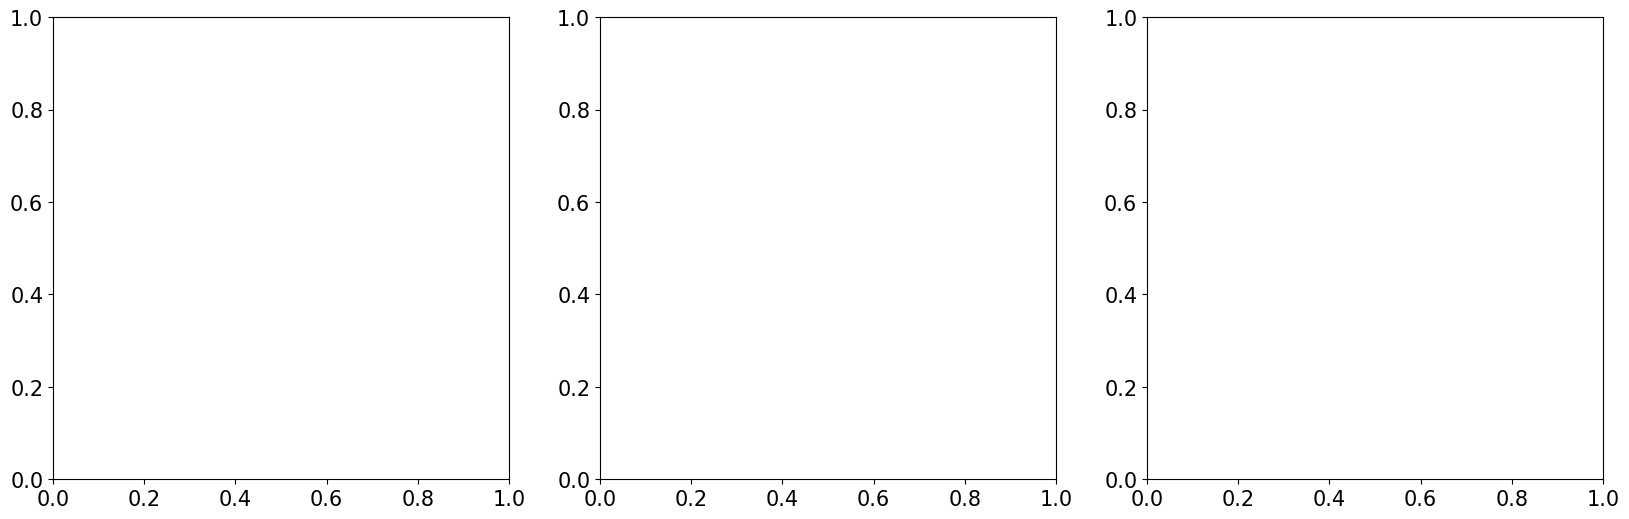

In [17]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams.update({'font.size': 15})

fig, ax = plt.subplots(1, 3, figsize=(20, 6))  # 1 hàng, 3 cột
fig_subtitle = ['a', 'b', 'c']

# Ensure arrays are NumPy (n_steps, N_UAVs)
RUAV_multi_true = np.array(RUAV_log)

for idx in range(3):
    ax[idx].plot(RUAV_multi_true[:, idx], c='C0')
    ax[idx].set_xlabel(f'Time step\n({fig_subtitle[idx]}) UAV {idx+1}')
    ax[idx].set_ylabel('USER DATARATE')
    ax[idx].grid()
    ax[idx].set_xlim([0, 300])
    ax[idx].set_xticks(np.arange(0, 300+1, 150))

# Add a global legend for all subplots
plt.figlegend(['MARL'], ncol=4, loc='upper center', bbox_to_anchor=(0.5, 1.))

plt.tight_layout(rect=[0, 0, 1, 0.95])  # tránh chồng legend
plt.show()
#

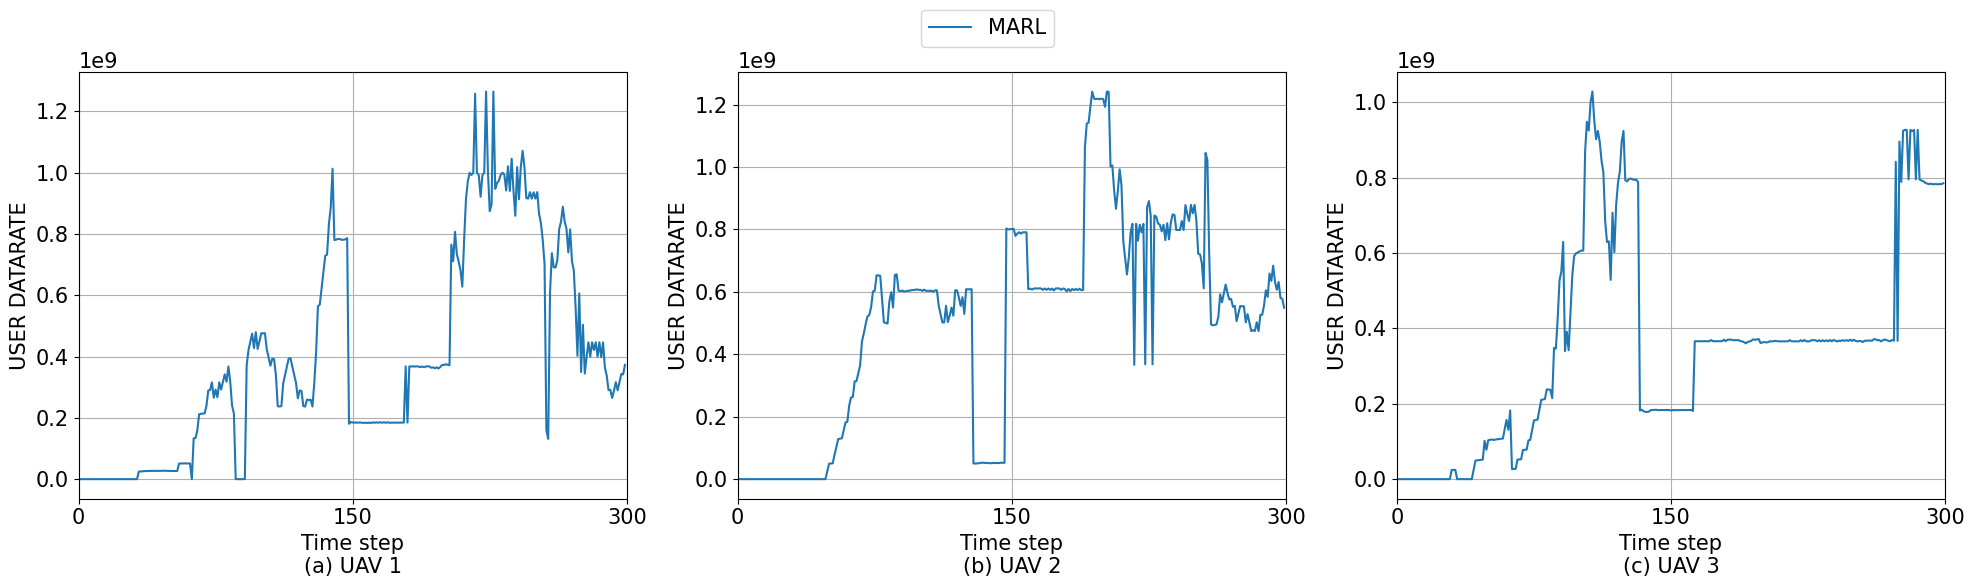

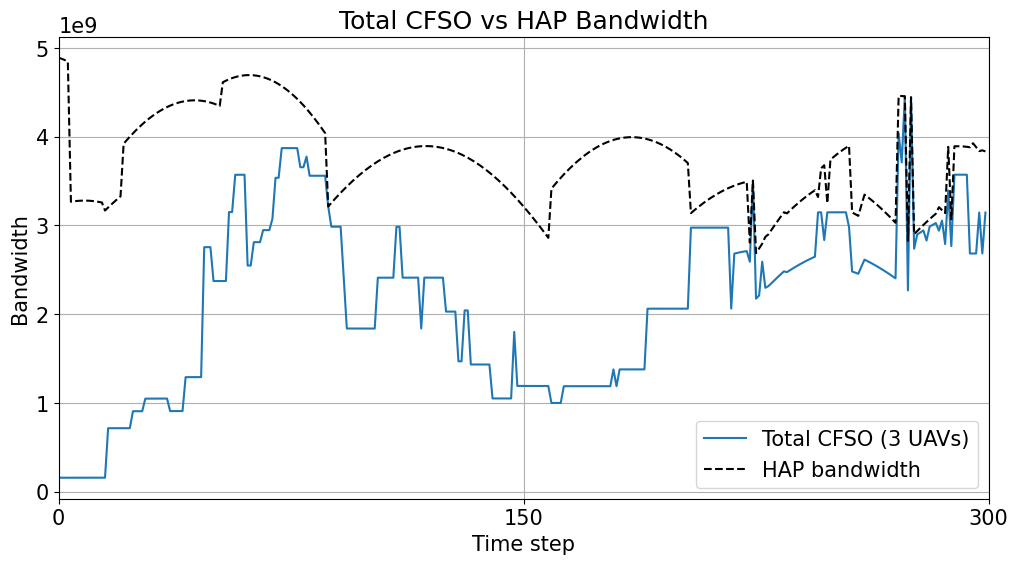

In [18]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams.update({'font.size': 15})
n_test_steps = 300
# Chuyển log sang numpy arrays
RUAV_multi_true = np.array(RUAV_log_DQN)      # (n_steps, 3)
CFSO_multi_true = np.array(CFSO_log_DQN)      # (n_steps, 3)
HAP_bw_true = np.array(HAP_bw_log_DQN)        # (n_steps, )

fig, ax = plt.subplots(1, 3, figsize=(20, 6))  # RUAV plots
fig_subtitle = ['a', 'b', 'c']

# --- RUAV cho 3 UAV ---
for idx in range(3):
    ax[idx].plot(RUAV_multi_true[:, idx], c='C0')
    ax[idx].set_xlabel(f'Time step\n({fig_subtitle[idx]}) UAV {idx+1}')
    ax[idx].set_ylabel('USER DATARATE')
    ax[idx].grid()
    ax[idx].set_xlim([0, n_test_steps])
    ax[idx].set_xticks(np.arange(0, n_test_steps+1, 150))

plt.figlegend(['MARL'], ncol=4, loc='upper center', bbox_to_anchor=(0.5, 1.))
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# --- Đồ thị riêng: tổng CFSO & HAP_bw ---
plt.figure(figsize=(12, 6))

CFSO_total = CFSO_multi_true.sum(axis=1)  # tính tổng theo 3 UAV
plt.plot(CFSO_total, label='Total CFSO (3 UAVs)')
plt.plot(HAP_bw_true, 'k--', label='HAP bandwidth')

plt.xlabel("Time step")
plt.ylabel("Bandwidth")
plt.title("Total CFSO vs HAP Bandwidth")
plt.grid()
plt.xlim([0, n_test_steps])
plt.xticks(np.arange(0, n_test_steps+1, 150))
plt.legend()
plt.show()


In [4]:
type_SAT="DQN"  # random, best, DQN
RUAV_log_DQN, CFSO_log_DQN, uav_traj_DQN, alpha_all_DQN, beta_all_DQN, HAP_bw_log_DQN, nums_handover_DQN= evaluate_trained_policy(
    sat_per_step,device, num_uav, num_steps,
    uav_pos_init, user_positions, cloud_map, HAP_position, type_SAT, save_dir="D:\TOPIC 3\Minh_code\model_save"
)

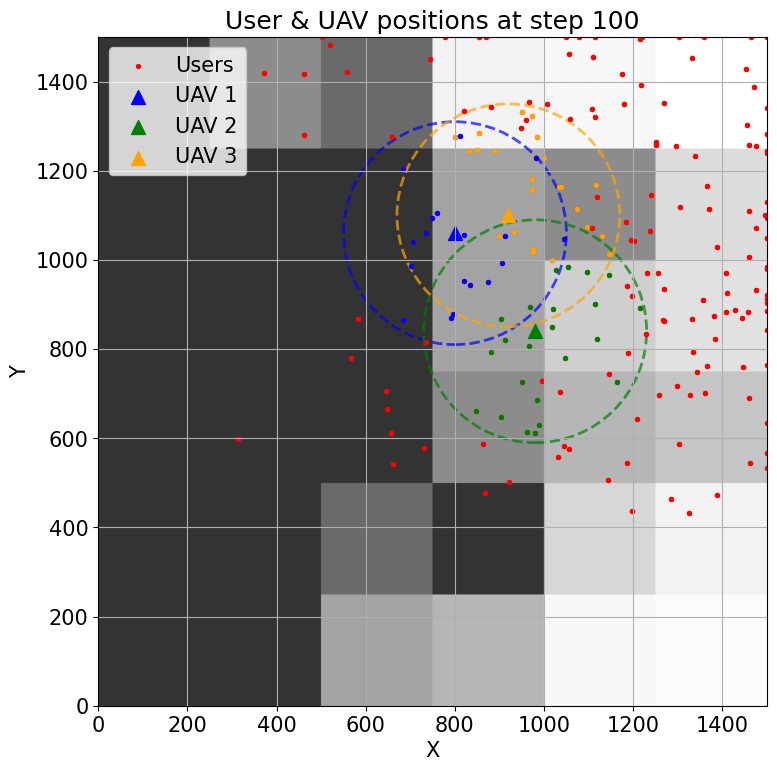

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

step = 100
x_start = 10 * step
x_end = x_start + 1500
cloud_slice = cloud_map[:, 0:1500]  # (1500, 1500)

# ==== Lấy vị trí người dùng ====
users_x = user_positions[:, step, 0]
users_y = user_positions[:, step, 1]

# ==== Lấy vị trí UAV ====
uav_xy = uav_traj_DQN[step][:, :2]   # (num_uav, 2)

# ==== Vẽ biểu đồ ====
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(cloud_slice, extent=[0, 1500, 0, 1500], cmap=cm.Greys, origin='lower', alpha=0.8)
ax.scatter(users_x, users_y, color='red', s=8, label='Users')

colors = ['blue', 'green', 'orange']  # 3 UAV, mỗi UAV một màu
for i in range(uav_xy.shape[0]):
    ax.scatter(uav_xy[i, 0], uav_xy[i, 1], 
               color=colors[i], marker="^", s=100, label=f"UAV {i+1}")
    # Vẽ vòng tròn bán kính 250m
    circle = plt.Circle((uav_xy[i, 0], uav_xy[i, 1]), 250, 
                        color=colors[i], fill=False, linestyle="--", linewidth=2, alpha=0.7)
    ax.add_patch(circle)
alpha_step = alpha_all_DQN[step]  # (num_users, num_uav)

for u in range(users_x.shape[0]):
    uav_idx = np.where(alpha_step[u, :] == 1)[0]  # tìm UAV kết nối
    if len(uav_idx) > 0:
        color = colors[uav_idx[0]]  # nếu kết nối nhiều UAV, lấy đầu tiên
    else:
        color = 'red'  # không kết nối UAV nào
    ax.scatter(users_x[u], users_y[u], color=color, s=8)
ax.set_title(f"User & UAV positions at step {step}")
ax.set_xlim(0, 1500)
ax.set_ylim(0, 1500)
ax.legend()
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.grid(True)
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

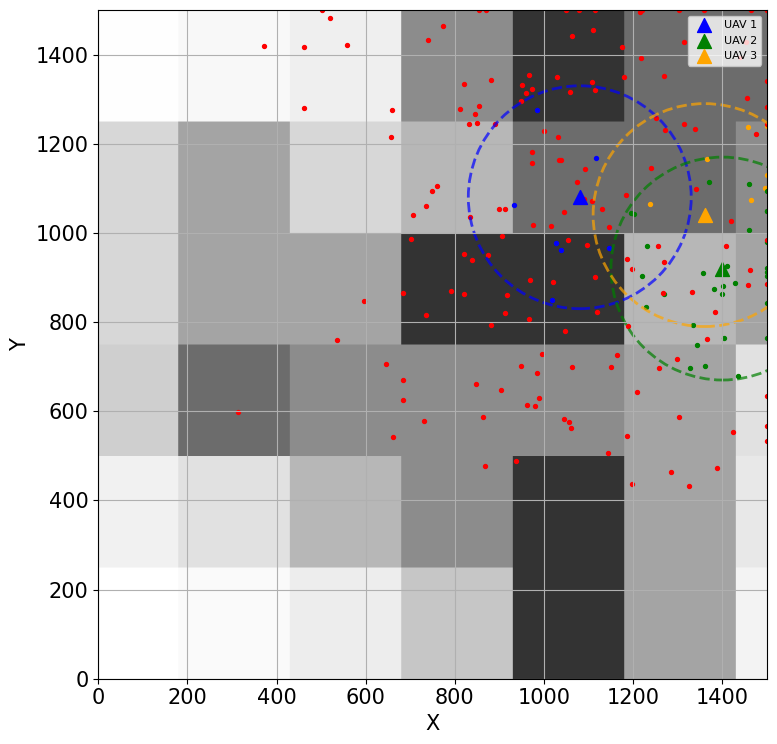

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import imageio

# ==== Cấu hình ====
step_start = 0
step_end = 300       # số bước tạo GIF
step_interval = 1
colors = ['blue', 'green', 'orange']  # UAV colors
gif_filename = 'uav_users.gif'

num_uav = uav_traj_DQN[0].shape[0]
num_users = user_positions.shape[0]
cloud_gif = cloud_map.copy()
with imageio.get_writer(gif_filename, mode='I', duration=0.1) as writer:
    for step in range(step_start, step_end, step_interval):
        # ---- Lấy slice cloud ----
        
        cloud_slice,_,new_cloud = get_clwc_map(cloud_gif)  # (1500, 1500)
        cloud_gif = new_cloud
        cloud_slice_small = cloud_slice[::2, ::2]  # giảm độ phân giải để tiết kiệm RAM
        extent = [0, 1500, 0, 1500]

        # ---- Vị trí user & UAV ----
        users_x = user_positions[:, step, 0]
        users_y = user_positions[:, step, 1]
        uav_xy = uav_traj_DQN[step][:, :2]

        # ---- Kết nối user-UAV ----
        alpha_step = np.array(alpha_all_DQN[step])  # (num_users, num_uav)

        # ---- Vẽ figure ----
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(cloud_slice_small, extent=extent, cmap=cm.Greys, origin='lower', alpha=0.8)

        # Vẽ user theo màu UAV kết nối
        for u in range(num_users):
            uav_idx = np.where(alpha_step[u, :] == 1)[0]
            if len(uav_idx) > 0:
                color = colors[uav_idx[0]]  # nếu kết nối nhiều UAV, lấy đầu tiên
            else:
                color = 'red'  # không kết nối UAV nào
            ax.scatter(users_x[u], users_y[u], color=color, s=8)

        # Vẽ UAV và vòng tròn 250m
        for i in range(num_uav):
            ax.scatter(uav_xy[i, 0], uav_xy[i, 1],
                       color=colors[i], marker="^", s=100, label=f"UAV {i+1}")
            circle = plt.Circle((uav_xy[i, 0], uav_xy[i, 1]), 250,
                                color=colors[i], fill=False, linestyle="--", linewidth=2, alpha=0.7)
            ax.add_patch(circle)

        ax.set_xlim(0, 1500)
        ax.set_ylim(0, 1500)
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.grid(True)
        ax.legend(loc='upper right', fontsize=8)
        plt.tight_layout()

        # ---- Chuyển figure -> array và ghi vào GIF ----
        # ---- Chuyển figure -> array và ghi vào GIF ----
        fig.canvas.draw()
        # Lấy kích thước figure
        w, h = fig.canvas.get_width_height()
        # Lấy buffer RGBA
        image = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
        # Chuyển thành shape (H, W, 4)
        image = image.reshape((h, w, 4))
        # Bỏ alpha, lấy RGB
        image = image[:, :, :3]
        writer.append_data(image)
        plt.close(fig)

        plt.close(fig)  # giải phóng RAM

print(f"GIF saved as {gif_filename}")


In [3]:
def select_action_topk_2(topk_list, Q_nets, obs, prev_selected_sat=None, epsilon=0.1):
    n_valid = len(topk_list)


    if isinstance(obs, np.ndarray):
        obs = torch.tensor(obs, dtype=torch.float32)

    # đưa obs cùng device với mạng
    obs = obs.to(next(Q_nets.parameters()).device)
    if n_valid == 0:
        return None, None, 0  # không có vệ tinh để chọn

    # print(obs)
    # Q-values toàn bộ actions
    q_values = Q_nets(obs.unsqueeze(0)).squeeze(0)  # (N_actions,)

    # chỉ lấy Q-values của các vệ tinh trong danh sách
    sat_indices = list(range(len(topk_list)))
    q_subset = q_values[sat_indices]
    # print(q_subset)
    # chọn best trong subset
    best_local_idx = torch.argmax(q_subset).item()
    action_idx = best_local_idx  # index trong topk_list

    selected_sat_name = topk_list[action_idx][0]

    # giữ kết nối nếu trùng vệ tinh step trước
    keep_idx = 1 if prev_selected_sat is not None and selected_sat_name == prev_selected_sat else 0

    return action_idx, selected_sat_name, keep_idx

In [4]:
class QNetwork_HAP(nn.Module):
    def __init__(self, n_observations, n_actions):
        super(QNetwork_HAP, self).__init__()
        # 3 hidden layers, mỗi layer 256 neurons
        self.layer1 = nn.Linear(n_observations, 256)
        self.layer2 = nn.Linear(256, 256)
        self.layer3 = nn.Linear(256, 256)
        self.output = nn.Linear(256, n_actions)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.relu(self.layer3(x))
        return self.output(x)

In [15]:
def build_observation_hap(step_idx, results_per_step, cfso_uav_list, topk=10):

    top_list = results_per_step.get(step_idx, [])

    # khởi tạo vector vt và cfso vệ tinh
    vt_vec = np.zeros(topk, dtype=float)
    cfso_vec = np.zeros(topk, dtype=float)

    # điền dữ liệu từ top_list (nếu ít hơn topk thì phần còn lại vẫn là 0)
    for i, (sat_name, elev, vt, slant, c_fso,coords) in enumerate(top_list[:topk]):
        vt_vec[i] = vt/300
        cfso_vec[i] = c_fso

    # đảm bảo cfso_uav_list là np.array
    cfso_uav_vec = np.array(cfso_uav_list, dtype=float)

    # concat thành observation
    obs = np.concatenate([vt_vec, cfso_vec, cfso_uav_vec])
    return obs

In [19]:
def evaluate_trained_policy_2(
     sat_per_step,device, num_uav, num_steps,
    uav_pos_init, user_positions, cloud_map, HAP_position, type_SAT,save_dir="/kaggle/working/"
):
 
    
    Q_nets_UAV = [QNetwork_UAV(142, 5).to(device) for _ in range(num_uav)]
    Q_nets_HAP = QNetwork_HAP(23, 10).to(device)

    # --- Load HAP models ---
    Q_nets_HAP.load_state_dict(torch.load(os.path.join(save_dir, f"HAP\\HAP_ep{1000}.pth")))

    for i in range(num_uav):
        Q_nets_UAV[i].load_state_dict(torch.load(os.path.join(save_dir, f"UAV\\UAV{i}_ep{1200}.pth")))


    alpha, beta = None, None
    RUAV_log = []
    CFSO_log = []
    uav_traj = []
    HAP_bandwidth_log = []
    uav_pos = uav_pos_init.copy()
    alpha_all = []
    beta_all = []
    actions_uav = []
    sat_name_per_step = []
    region_t, clwc_map_t, new_cloud_map = get_clwc_map(cloud_map)
    current_satellite_id = None 
    prev_satellite_id = None
    nums_handover = 0

    for t in range(900):
        region_t, clwc_map_t, new_cloud_map = get_clwc_map(cloud_map)
        cloud_map = new_cloud_map
        user_pos_t = user_positions[:, t, :]
       
        alpha, beta, C_FSO_UAV_before = get_CFSO(
                uav_pos, user_positions[:,0,:], region_t, HAP_position, actions_uav, 0, device
            )
        
        obs_hap = build_observation_hap(t, sat_per_step, C_FSO_UAV_before/11318001312)
        obs_hap = torch.tensor(obs_hap, dtype=torch.float32, device=device)
        # print(f"Step {t}, Obs HAP: {obs_hap.cpu().numpy()}")
        sat_that_step = sat_per_step.get(t, [])
        if(type_SAT=="random"):
            action_idx, current_satellite_id, keep_idx = select_action_topk_random(
                            sat_that_step, current_satellite_id
                        )
        elif(type_SAT=="DQN"):
            action_idx, current_satellite_id, keep_idx =   select_action_topk_2(sat_that_step, Q_nets_HAP, obs_hap, prev_satellite_id)
        elif(type_SAT=="best"):
            action_idx, current_satellite_id, keep_idx = select_action_topk_cfso(
                                sat_that_step, current_satellite_id
                            )
        if(type_SAT == "DQN"):
            sat_name, elev, vt, slant, c_fso,coords = sat_that_step[action_idx]
        else:
            sat_name, elev, vt, slant, c_fso,coords = sat_that_step[action_idx]
            
        sat_info = {'sat_name': sat_name, 'elev': elev, 'vt': vt, 'slant': slant, 'c_fso': c_fso}
        HAP_bandwidth = sat_info['c_fso'] * 11318001312
        obs_uav = build_observations_vector(uav_pos, user_pos_t, clwc_map_t, alpha, beta)
        obs_uav = obs_uav.to(device)
        prev_satellite_id = current_satellite_id
        with torch.no_grad():
            actions = [Q_nets_UAV[i](obs_uav[i].unsqueeze(0)).argmax().item() for i in range(num_uav)]

        uav_pos = move_uavs(uav_pos, actions)
        next_region_t, next_clwc_map_t, new_cloud = get_clwc_map(cloud_map)
        next_user_pos_t = user_positions[:, t+1, :]

        rewards_uav, alpha, beta, RUAV, CFSO = user_association_and_reward_opti_2(
            uav_pos, next_user_pos_t, next_region_t, HAP_position, HAP_bandwidth, t, device
        )
        # if(type_SAT == "DQN"):
        #     if(action_idx != 0):
        #         nums_handover += 1
        if(keep_idx != 1):
                nums_handover += 1

        HAP_bandwidth_log.append(HAP_bandwidth)
        RUAV_log.append(RUAV.cpu().numpy() if isinstance(RUAV, torch.Tensor) else RUAV)
        CFSO_log.append(CFSO.cpu().numpy() if isinstance(CFSO, torch.Tensor) else CFSO)
        sat_name_per_step.append(current_satellite_id)
        alpha_all.append(alpha)
        beta_all.append(beta)
        uav_traj.append(uav_pos.copy())

    return RUAV_log, CFSO_log, uav_traj, alpha_all, beta_all, HAP_bandwidth_log, nums_handover,sat_name_per_step


In [21]:
type_SAT="DQN"  # random, best, DQN
RUAV_log_DQN, CFSO_log_DQN, uav_traj_DQN, alpha_all_DQN, beta_all_DQN, HAP_bw_log_DQN, nums_handover_DQN, sat_name_per_step= evaluate_trained_policy_2(
    sat_per_step,device, num_uav, num_steps,
    uav_pos_init, user_positions, cloud_map, HAP_position, type_SAT, save_dir="D:\TOPIC 3\Minh_code\model_save"
)

In [23]:
nums_handover_DQN

40

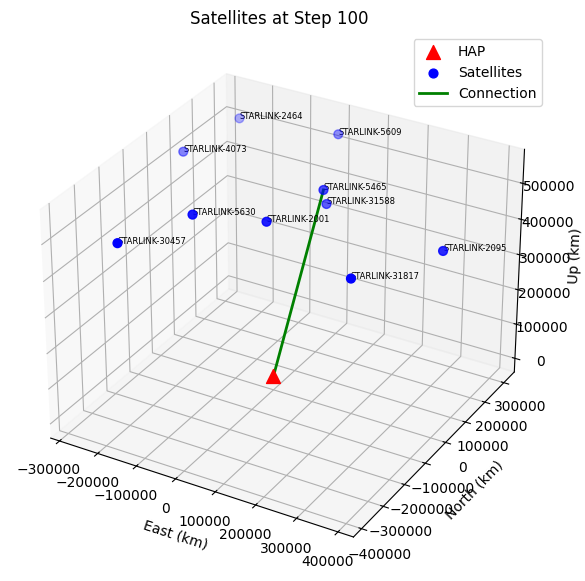

In [24]:
import matplotlib.pyplot as plt

def plot_one_step(sat_per_step, sat_name_per_step, HAP_position=(0,0,0), step=100):
    sat_list = sat_per_step.get(step, [])
    if not sat_list:
        print(f"Không có vệ tinh ở step {step}")
        return
    
    fig = plt.figure(figsize=(7,7))
    ax = fig.add_subplot(111, projection='3d')
    
    # Vẽ HAP
    hx, hy, hz = HAP_position
    ax.scatter(hx, hy, hz, c="red", marker="^", s=100, label="HAP")
    
    # Vẽ vệ tinh
    xs, ys, zs = [], [], []
    for sat in sat_list:
        sat_name, elev, vt, slant, c_fso, coords = sat
        x, y, z = coords
        xs.append(x); ys.append(y); zs.append(z)
        ax.text(x, y, z, sat_name.strip(), fontsize=6)

    ax.scatter(xs, ys, zs, c="blue", s=40, label="Satellites")
    
    # Vẽ kết nối
    chosen_sat_name = sat_name_per_step[step]
    for sat in sat_list:
        sat_name, elev, vt, slant, c_fso, coords = sat
        if sat_name.strip() == chosen_sat_name.strip():
            x, y, z = coords
            ax.plot([hx, x], [hy, y], [hz, z], c="green", linewidth=2, label="Connection")
            break
    
    ax.set_xlabel("East (km)")
    ax.set_ylabel("North (km)")
    ax.set_zlabel("Up (km)")
    ax.legend()
    plt.title(f"Satellites at Step {step}")
    plt.show()
plot_one_step(sat_per_step, sat_name_per_step, HAP_position=(0,0,0), step=100)


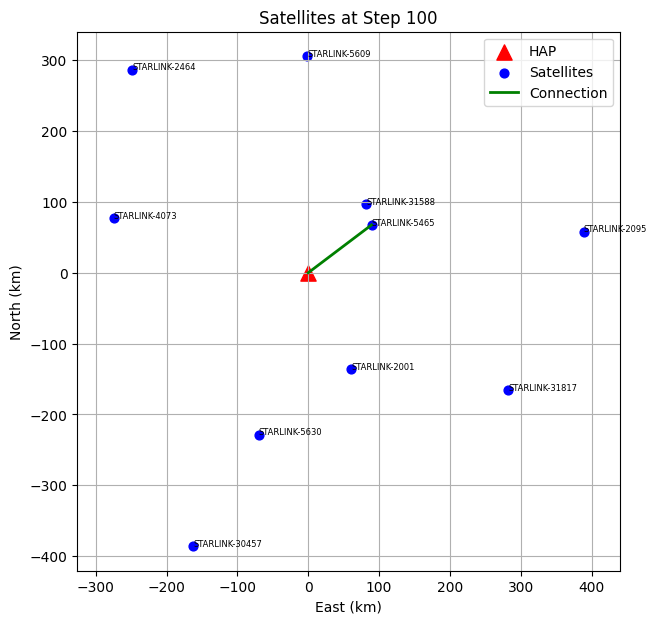

In [27]:
import matplotlib.pyplot as plt

def plot_one_step_2d(sat_per_step, sat_name_per_step, HAP_position=(0,0), step=100):
    sat_list = sat_per_step.get(step, [])
    if not sat_list:
        print(f"Không có vệ tinh ở step {step}")
        return
    
    plt.figure(figsize=(7,7))

    # Vẽ HAP ở gốc
    hx, hy = HAP_position
    plt.scatter(hx, hy, c="red", marker="^", s=120, label="HAP")

    # Vẽ vệ tinh
    xs, ys = [], []
    for sat in sat_list:
        sat_name, elev, vt, slant, c_fso, coords = sat
        x, y, z = coords   # coords là (East, North, Up)
        xs.append(x/1000.0)
        ys.append(y/1000.0)
        plt.text(x/1000.0, y/1000.0, sat_name.strip(), fontsize=6)

    plt.scatter(xs, ys, c="blue", s=40, label="Satellites")

    # Vẽ kết nối
    chosen_sat_name = sat_name_per_step[step]
    for sat in sat_list:
        sat_name, elev, vt, slant, c_fso, coords = sat
        if sat_name.strip() == chosen_sat_name.strip():
            x, y, z = coords
            plt.plot([hx, x/1000.0], [hy, y/1000.0], c="green", linewidth=2, label="Connection")
            break

    plt.xlabel("East (km)")
    plt.ylabel("North (km)")
    plt.title(f"Satellites at Step {step}")
    plt.legend()
    plt.grid(True)
    plt.axis("equal")
    plt.show()
plot_one_step_2d(sat_per_step, sat_name_per_step, HAP_position=(0,0), step=100)


In [30]:

import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

def create_satellite_gif_2d(sat_per_step, sat_name_per_step, HAP_position=(0,0), 
                            save_path="sat_animation.gif", steps=None, interval=200):
    if steps is None:
        steps = sorted(sat_per_step.keys())

    fig, ax = plt.subplots(figsize=(7,7))

    # HAP
    hx, hy = HAP_position
    hap_scatter = ax.scatter([hx], [hy], c="red", marker="^", s=120, label="HAP")

    # Scatter vệ tinh
    sat_scatter = ax.scatter([], [], c="blue", s=40, label="Satellites")

    # Đường kết nối
    connection_line, = ax.plot([], [], c="green", linewidth=2, label="Connection")

    # Label vệ tinh (cho tối đa 50 vệ tinh/step)
    sat_texts = [ax.text(0,0,"",fontsize=6) for _ in range(50)]  

    # 🔒 Cố định khung quan sát: -500km đến +500km quanh HAP
    ax.set_xlim(-500, 500)
    ax.set_ylim(-500, 500)
    ax.set_xlabel("East (km)")
    ax.set_ylabel("North (km)")
    ax.set_title("Satellites")
    ax.legend(fontsize=6, loc="best")
    ax.grid(True)
    ax.set_aspect("equal")

    def update(frame):
        step = steps[frame]
        sat_list = sat_per_step.get(step, [])

        xs, ys = [], []
        for i, sat in enumerate(sat_list):
            sat_name, elev, vt, slant, c_fso, coords = sat
            x, y, z = coords
            xs.append(x/1000.0)
            ys.append(y/1000.0)
            if i < len(sat_texts):
                sat_texts[i].set_position((x/1000.0, y/1000.0))
                sat_texts[i].set_text(sat_name.strip())
        # clear text thừa
        for j in range(len(sat_list), len(sat_texts)):
            sat_texts[j].set_text("")

        sat_scatter.set_offsets(np.c_[xs, ys])

        # Vẽ kết nối nếu có
        if frame < len(sat_name_per_step):
            chosen_sat_name = sat_name_per_step[frame]
            found = False
            for sat in sat_list:
                sat_name, elev, vt, slant, c_fso, coords = sat
                if sat_name.strip() == chosen_sat_name.strip():
                    x, y, z = coords
                    connection_line.set_data([hx, x/1000.0], [hy, y/1000.0])
                    found = True
                    break
            if not found:
                connection_line.set_data([], [])
        else:
            connection_line.set_data([], [])

        return sat_scatter, connection_line, *sat_texts

    ani = animation.FuncAnimation(fig, update, frames=len(steps), interval=interval, blit=False)
    ani.save(save_path, writer="pillow")
    plt.close(fig)
    print(f"GIF đã lưu tại {save_path}")

create_satellite_gif_2d(sat_per_step, sat_name_per_step, save_path="satellite_demo.gif", interval=300)


GIF đã lưu tại satellite_demo.gif


In [31]:
nums_handover_DQN

40